# Actividad Clase 7 · Optimización de carteras: clásica, HRP y HERC
### Acciones del S&P Merval, 2020-2026

Métodos Predictivos Aplicados a las Finanzas – Parte II · UBA · Docente: Rodrigo Del Rosso · **Giovanni Raffo**

**Consigna:** con las acciones del S&P Merval desde enero de 2020: (1) optimización clásica; (2) comparación con HRP y HERC; (3) VaR por el método delta normal de cada cartera; (4) optimización dinámica con rebalanceo diario.

Se usa Riskfolio-Lib, la librería de la clase. Se fija la versión 7.2.1 porque la 7.3.0 tiene un error al calcular HERC.

In [1]:
%pip install -q riskfolio-lib==7.2.1

Note: you may need to restart the kernel to use updated packages.


## 1. Activos y datos

Las 23 acciones del S&P Merval (composición de marzo de 2025), con precios de cierre ajustados en pesos de Yahoo Finance desde enero de 2020. Se descartan con código las acciones con saltos diarios de más de 50 %: no son movimientos reales, sino divisiones de acciones sin ajustar o precios sin operaciones.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import riskfolio as rp
import warnings
warnings.filterwarnings("ignore")

merval = ["ALUA", "BBAR", "BMA", "BYMA", "CEPU", "COME", "CRES", "CVH", "EDN", "GGAL", "HARG", "LOMA",
          "MIRG", "PAMP", "SUPV", "TECO2", "TGNO4", "TGSU2", "TRAN", "TXAR", "VALO", "YPFD", "AGRO"]
precios = yf.download([a + ".BA" for a in merval], start="2020-01-01", end="2026-09-23", auto_adjust=True, progress=False)["Close"]
precios.columns = precios.columns.str.replace(".BA", "")
precios.to_csv("precios_merval.csv")

rendimientos = precios.pct_change().dropna()
saltos = rendimientos.columns[(rendimientos.abs() > 0.5).any()]
rendimientos = rendimientos.drop(columns=saltos)
print("Descartadas:", list(saltos), "| Acciones:", rendimientos.shape[1], "| Días:", len(rendimientos))

Descartadas: ['AGRO', 'HARG', 'MIRG'] | Acciones: 20 | Días: 1643


**Lectura:** quedan 20 acciones y 1.643 días. Se descartan HARG, AGRO y MIRG: por ejemplo, MIRG pasa de 16.350 a 1.640 pesos en un día, una división de acciones que la fuente no ajustó.

## 2. Las tres carteras

- **Clásica (Markowitz):** la cartera de máximo Sharpe de la frontera eficiente, con rendimientos y covarianzas históricos.
- **HRP (paridad de riesgo jerárquica):** agrupa las acciones por correlación en un árbol y reparte el capital de arriba hacia abajo, con más peso para las ramas de menor varianza. No necesita invertir la matriz de covarianzas.
- **HERC (contribución jerárquica igual al riesgo):** usa el mismo tipo de árbol, lo corta en el número óptimo de grupos y hace que cada grupo aporte el mismo riesgo.

Mismos parámetros que los ejemplos de la clase: correlación de Pearson, varianza como medida de riesgo, tasa libre de riesgo 0, vinculación *single* para HRP y *ward* para HERC.

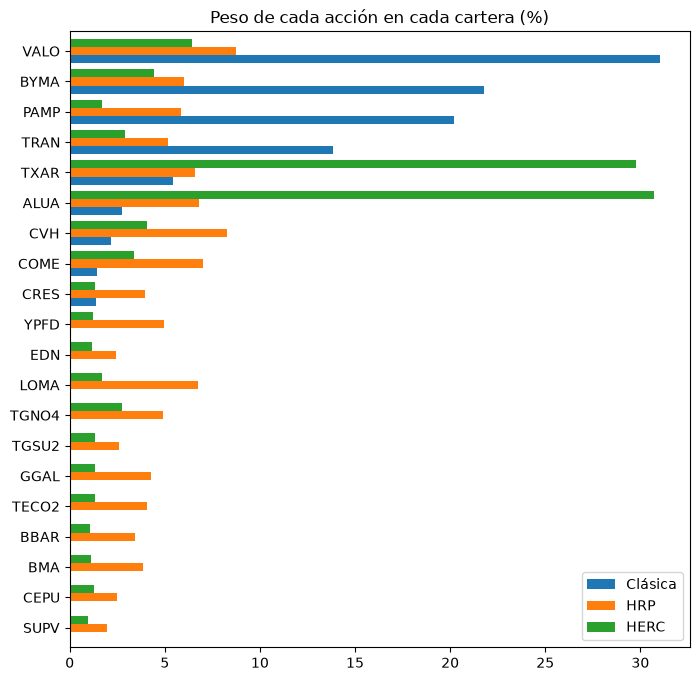

In [3]:
def optimizar(r):
    clasica = rp.Portfolio(returns=r)
    clasica.assets_stats(method_mu="hist", method_cov="hist")
    jerarquica = rp.HCPortfolio(returns=r)
    return pd.concat([
        clasica.optimization(model="Classic", rm="MV", obj="Sharpe", rf=0, hist=True),
        jerarquica.optimization(model="HRP", codependence="pearson", rm="MV", rf=0, linkage="single", leaf_order=True),
        jerarquica.optimization(model="HERC", codependence="pearson", rm="MV", rf=0, linkage="ward", max_k=10, leaf_order=True),
    ], axis=1).set_axis(["Clásica", "HRP", "HERC"], axis=1)

pesos = optimizar(rendimientos)
(pesos * 100).sort_values("Clásica").plot.barh(figsize=(8, 8), width=0.8, title="Peso de cada acción en cada cartera (%)")
plt.show()

In [4]:
def resumen(r):
    valor = (1 + r).cumprod()
    return pd.Series({
        "Rendimiento anual (%)": r.mean() * 252 * 100,
        "Volatilidad anual (%)": r.std() * np.sqrt(252) * 100,
        "Sharpe": r.mean() / r.std() * np.sqrt(252),
        "Máxima caída (%)": (valor / valor.cummax() - 1).min() * 100,
    })

comparacion = pd.DataFrame({m: resumen(rendimientos @ pesos[m]) for m in pesos})
comparacion.loc["Acciones con más de 1 %"] = (pesos > 0.01).sum()
comparacion.loc["Peso máximo (%)"] = pesos.max() * 100
comparacion.round(2)

,Clásica,HRP,HERC
Rendimiento anual (%),77.26,76.35,70.59
Volatilidad anual (%),36.41,39.76,40.78
Sharpe,2.12,1.92,1.73
Máxima caída (%),-38.24,-47.21,-49.07
Acciones con más de 1 %,9.00,20.00,19.00
Peso máximo (%),31.04,8.76,30.70


**Lectura:**
- **Clásica:** concentra el capital en 9 acciones y 73 % en solo tres (VALO 31 %, BYMA 22 %, PAMP 20 %). Tiene el mejor Sharpe (2,12), algo esperable: se optimizó con los mismos datos con los que se mide.
- **HRP:** reparte entre las 20 acciones, ninguna con más de 9 %. Sharpe 1,92.
- **HERC:** forma 3 grupos. ALUA y TXAR (aluminio y acero, exportadoras) son un grupo propio, poco correlacionado con el resto, y reciben 60 % del capital. Las 12 acciones más ligadas a la economía local (bancos, energía, servicios) se mueven casi juntas y, como grupo, reciben solo 16 %. Sharpe 1,73.

## 3. VaR por el método delta normal

Supone rendimientos normales: la pérdida que no se supera en un día con 95 % de confianza es 1,645 veces la volatilidad diaria de la cartera, que se calcula con la matriz de covarianzas, σ = √(w'Σw). Se supone rendimiento medio diario cero. Se expresa en % y sobre una cartera de $1.000.000.

In [5]:
covarianzas = rendimientos.cov()
volatilidad = pd.Series({m: np.sqrt(pesos[m] @ covarianzas @ pesos[m]) for m in pesos})
pd.DataFrame({
    "Volatilidad diaria (%)": volatilidad * 100,
    "VaR 95 % a 1 día (%)": 1.645 * volatilidad * 100,
    "VaR sobre $1.000.000": 1.645 * volatilidad * 1000000,
}).round(2)

,Volatilidad diaria (%),VaR 95 % a 1 día (%),VaR sobre $1.000.000
Clásica,2.29,3.77,37733.03
HRP,2.50,4.12,41200.73
HERC,2.57,4.23,42260.81


**Lectura:** con los datos completos, la cartera clásica es la de menor riesgo: VaR de 3,77 % (unos 37.700 pesos sobre un millón), contra 4,12 % de HRP y 4,23 % de HERC. Pero es una medición dentro de la muestra; la sección 4 muestra qué pasa cuando las carteras se usan hacia adelante.

## 4. Optimización dinámica con rebalanceo diario

Cada día se recalculan las tres carteras con los rendimientos del último año (252 días) y se invierte con esos pesos al día siguiente. Así cada cartera se evalúa con datos que no usó para armarse, desde enero de 2021. La **rotación** es la suma de los cambios de pesos de un día al siguiente: cuánto hay que operar para rebalancear.

In [6]:
ventana = 252
pesos_diarios, rendimiento_diario = [], []
for dia in range(ventana, len(rendimientos)):
    w = optimizar(rendimientos.iloc[dia - ventana:dia])
    pesos_diarios.append(w)
    rendimiento_diario.append(rendimientos.iloc[dia] @ w)
dinamico = pd.DataFrame(rendimiento_diario, index=rendimientos.index[ventana:])

tabla = pd.DataFrame({m: resumen(dinamico[m]) for m in dinamico})
tabla.loc["VaR 95 % a 1 día (%)"] = 1.645 * dinamico.std() * 100
tabla.loc["Rotación diaria (%)"] = sum((a - b).abs() for a, b in zip(pesos_diarios[1:], pesos_diarios)).sum() / (len(pesos_diarios) - 1) * 100
tabla.round(2)

,Clásica,HRP,HERC
Rendimiento anual (%),67.64,82.66,83.86
Volatilidad anual (%),39.91,37.69,38.60
Sharpe,1.69,2.19,2.17
Máxima caída (%),-50.69,-38.76,-39.81
VaR 95 % a 1 día (%),4.14,3.91,4.00
Rotación diaria (%),13.83,8.02,10.76


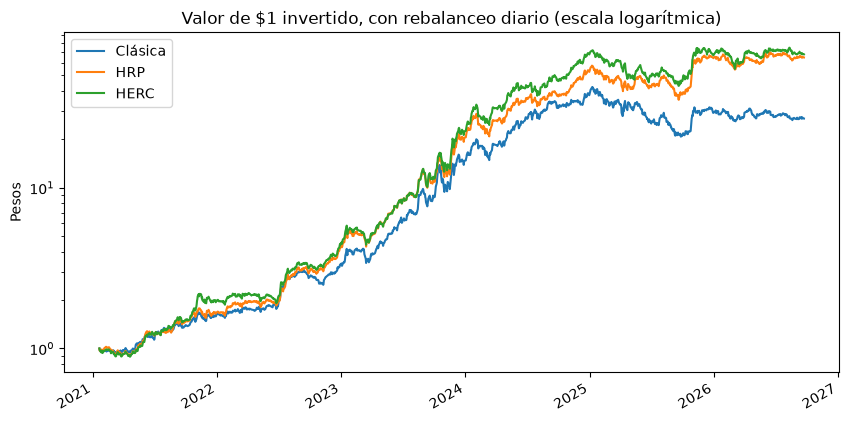

In [7]:
(1 + dinamico).cumprod().plot(logy=True, figsize=(10, 5), title="Valor de $1 invertido, con rebalanceo diario (escala logarítmica)", xlabel="", ylabel="Pesos")
plt.show()

**Lectura:** usadas hacia adelante, el orden se invierte. HRP y HERC superan a la clásica en todo: más rendimiento (83 % y 84 % anual contra 68 %), mejor Sharpe (2,19 y 2,17 contra 1,69), menor VaR (3,91 % y 4,00 % contra 4,14 %) y una caída máxima mucho menor (−39 % y −40 % contra −51 %). Además rotan menos: la clásica cambia 14 % de la cartera por día y HRP, 8 %. HRP es la de menor riesgo.

## 5. Cierre

| Punto de la consigna | Qué se hizo |
|---|---|
| Optimización clásica, S&P Merval desde 2020 | Máximo Sharpe de Markowitz con 20 acciones del índice, de enero de 2020 a septiembre de 2026 |
| Comparar con HRP y HERC | Pesos, concentración, rendimiento, volatilidad, Sharpe y caída máxima de las tres carteras |
| VaR delta normal, ¿cuál tiene menor riesgo? | En la muestra completa, la clásica (3,77 %). Usadas hacia adelante, HRP (3,91 %) |
| Optimización dinámica con rebalanceo diario | Reoptimización diaria con el último año de datos: HRP y HERC superan a la clásica en todas las métricas |

**Conclusión:** la cartera clásica es la mejor solo en los datos con los que se optimizó; concentra el capital en pocas acciones y cambia mucho de un día al siguiente. HRP y HERC, que diversifican según la estructura de correlaciones, son más estables y rinden más con menos riesgo cuando se usan hacia adelante, como anticipa López de Prado (2016). Los rendimientos están en pesos, sin ajustar por inflación, y no se consideran costos de transacción.